# DISRA Module: SCDD-GG-12

**TITLE:** Counting Extremely Faint Galaxies with HWO to Measure the Dark Matter Power Spectrum

**AUTHORS:** Jess Doppel, Leonidas Moustakas, Nathan Nadler

**Name:** Dwarf Galaxies

**GOAL:** What is the nature of Dark Matter?

**OBJECTIVE:** Measure the abundances of ultra-faint dwarf galaxies to constrain the nature of dark matter

**CODE PURPOSE:** Calculate the detection feasibility of individual RGB stars to infer the stellar mass of ultra-faint dwarf galaxy hosts in the local universe, and place constraints on warm dark matter mass limit.

**BACKGROUND:**

The nature of dark matter directly impacts the formation and evolution of cosmic structure. Relative to the standard cold dark matter (CDM) paradim, Warm Dark Matter (WDM) and Self-interacting dark matter (SIDM) supress small-scale structure formation, and the abundance of low mass halos can thus be used to constrain the mass of DM particle in a given DM model.

The DM halo mass function can be inferred from the count and stellar mass of dwarf galaxies, assuming the galaxy-halo relation is known, while the stellar mass can be inferred from the count of individual RGB stars through a stellar population synthesis code (artpop). The WDM mass constraint is forecasted to be a function of the limiting stellar mass $M_{*,lim}$ and number of Milky Way-like host galaxies, $N_{host}$ (Figure 7).

This DISRA calculates the required sensitivity to survey individual RGB stars in dwarf galaxies in the Local Volume (upto 10-Mpc distance). A deep survey to $M_{*,lim} \sim 10^{3.5}$ and $N_{host}=10$ will enable major progress.

Nadler et al. 2024 provides the forecasting framework for dwarf galaxies. The other details are in the SCDD.

**MODIFICATION HISTORY:**

[2025-06-02] Written by Tzu-Ching Chang

[2026-04-09] Text edits by Aki Roberge

In [1]:
#Import Bokeh interface tools
from ipywidgets import interact
from bokeh.io import push_notebook, show, output_notebook
from bokeh.plotting import figure
from bokeh.layouts import column
output_notebook()

from hwo_disra.api.notebook_api import DisraNBApi
api = DisraNBApi.get_instance()

#Import numpy, syotools, and astropy.units
import numpy as np
#from syotools import cdbs #make sure that pysynphot can find its reference files!
from syotools.models import Telescope, Camera, Spectrograph #models for the observatory and instruments
from syotools.utils.jsonunit import str_jsunit #for printing JsonUnit and JsonSpectrum wrappers in a readable way
from syotools.utils import pre_encode, pre_decode
from syotools.spectra import SpectralLibrary
import astropy.units as u

import pickle
import scipy
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline

Loading BokehJS ...

  points: [1136.3 1142.3 1142.4 1142.5 1152.7]
  lookup_table: [-9.31015728e-07 -2.34371190e-07 -2.17769838e-06 -1.89383420e-06
 -1.86404638e-07] [synphot.models]
  points: [1170.     1170.5    1171.3    ... 2241.1    2241.2001 2241.3   ]
  lookup_table: [-3.99896421e-07 -3.16809265e-06 -1.49050587e-06 ... -8.56435582e-07
 -9.55618745e-07 -4.15987490e-08] [synphot.models]
  points: [1180.5 1181.5 1241.5 1244.5 1248.5 1249.5 1262.5 1290.5 1307.5 1310.5
 1312.5 1315.5 1316.5 1317.5 1318.5 1321.5 1330.5 1333.5 1341.5 1342.5
 1343.5 1345.5 1346.5 1348.5 1352.5 1370.5 1372.5 1379.5 1380.5 1384.5
 1386.5 1387.5 1388.5 1389.5 1391.5 1395.5 1399.5 1400.5 1426.5 1427.5
 1428.5 1429.5 1434.5 1447.5 1448.5 1449.5 1450.5 1454.5 1455.5 1456.5
 1461.5 1466.5 1474.5 1475.5 1482.5 1493.5 1498.5 1505.5 1519.5 1539.5
 1558.5 1563.5 1567.5 1569.5 1570.5 1575.5 1577.5 1579.5 1581.5 1582.5
 1584.5 1589.5 1590.5 1591.5 1592.5 1594.5 1595.5 1596.5 1599.5 1600.5
 1601.5 1605.5 1606.5 1607.5 1608.5 1609.5 1612

# Science Return vs. Observation Quality (Panel 1)

In [2]:
#Instatiate the observatory using syotools.models.Telescope
#This loads the default Telescope values, which are already based on the HWO design
# Note: set_from_sei loads the SEI (Systems Engineering Information) YAML data, which
# populates telescope_efficiency (mirror throughput) and effective_aperture. The older
# set_from_json path does not load telescope_efficiency, which the new syotools
# SourceExposure model requires.
hwo_ex1 = Telescope()
hwo_ex1.set_from_sei('EAC2')

In [3]:
#Instantiate the instrument, using syotools.models.Camera, and link it with the telescope
#This loads the default Camera values, which are already based on the HWO-HRI design
# set_from_sei populates the instrument_efficiency_uvis and instrument_efficiency_nir
# attributes from the SEI YAML data, which are needed by the SourceExposure model.
hri = Camera()
hri.set_from_sei('HRI')
hwo_ex1.add_camera(hri)

In [20]:
# Quary the WDM mass limit as a function of log_Mstar and N_host through a pre-computed spline from Ethan Nadler's work
# (Figure 7 of SCDD 12)
# This spline is based on the results of the Bolshoi-Planck simulation, and is used to estimate the WDM mass limit
# as a function of the stellar mass of the host galaxy and the number of hosts in the simulation.

with open('logMstar_Nhost_m_wdm_lim_spline.pkl', 'rb') as f:
    interp_spline = pickle.load(f)

# Only fit between log_Mstar \in [2.14503,5.94503]; the result won't change outside this range, but the code won't break!
# It's possible input any (non-integer) N_host
log_Mstar_eval = 3.5
N_host_eval = 8

#3-sigma m_wdm_lim in keV
print(interp_spline(log_Mstar_eval, N_host_eval)[0][0])

def get_wdm_mass_limit(log_Mstar, N_host):
    """
    Returns the 3-sigma WDM mass limit (in keV) for given log_Mstar and N_host using the precomputed spline.

    Parameters:
        log_Mstar (float): log10 of the stellar mass.
        N_host (float): Number of host galaxies, should be a integer but float is accepted.
        spline (RectBivariateSpline): Precomputed spline object (default: interp_spline).

    Returns:
        float: 3-sigma WDM mass limit in keV.
    """
    # file from Ethan Nadler's work (Figure 7 of SCDD 12)
    # with open('logMstar_Nhost_m_wdm_lim_spline.pkl', 'rb') as f:
    #     interp_spline = pickle.load(f)

    return interp_spline(log_Mstar, N_host)[0][0]

20.067901400580684


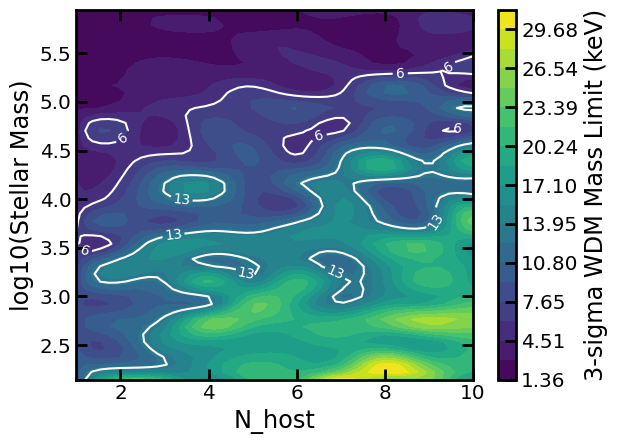

In [21]:
# Reproduce SCDD 12 Figure 7
# Create a grid of log_Mstar and N_host values and compute the WDM mass limit for each combination

from hwo_disra.Types import Range, ScienceValue


log_Mstar_range = np.linspace(2.14503, 5.94503, 100)  # log10 of stellar mass range
N_host_range = np.arange(1, 11)  # N_host range from 1 to 10

mass_limit_yield = api.yieldinator("wdm mass limit", yield_function=get_wdm_mass_limit,
                                   variables={"log_Mstar": Range(min=2.14503, max=5.94503, units=u.keV),
                                              "N_host": Range(min=1, max=10, units=int)},
                                   thresholds={ScienceValue.ENHANCING: 6,
                                               ScienceValue.ENABLING: 13})

res = api.evaluate(mass_limit_yield, register=True)
api.contour_plot_yield(
    res,
    x_key='N_host',
    y_key='log_Mstar',
    z_key='yield_result',
    contour_levels=sorted(mass_limit_yield.thresholds().values()),
    axis_labels={
        'N_host': 'N_host',
        'log_Mstar': 'log10(Stellar Mass)',
        'yield_result': '3-sigma WDM Mass Limit (keV)',
    },
)

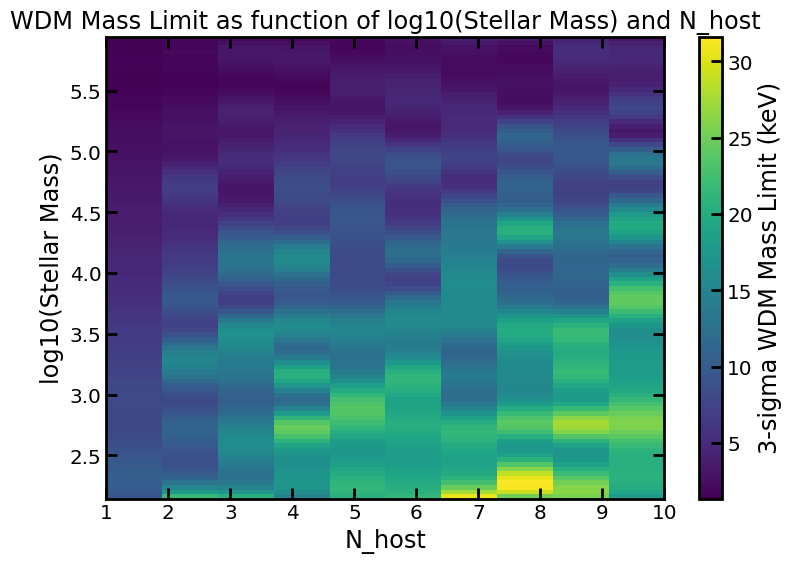

In [22]:
# Reproduce SCDD 12 Figure 7
# Create a grid of log_Mstar and N_host values and compute the WDM mass limit for each combination

log_Mstar_range = np.linspace(2.14503, 5.94503, 100)  # log10 of stellar mass range
N_host_range = np.arange(1, 11)  # N_host range from 1 to 10


# Create a grid of log_Mstar and N_host values
log_Mstar_grid, N_host_grid = np.meshgrid(log_Mstar_range, N_host_range)
wdm_mass_grid = np.array([[get_wdm_mass_limit(log_Mstar, N_host)
                           for log_Mstar in log_Mstar_range]
                          for N_host in N_host_range])

plt.figure(figsize=(9, 6))
im = plt.imshow(wdm_mass_grid.T, aspect='auto', origin='lower',
                extent=(N_host_range[0], N_host_range[-1],log_Mstar_range[0], log_Mstar_range[-1]),
                cmap='viridis')
plt.colorbar(im, label='3-sigma WDM Mass Limit (keV)')
plt.ylabel('log10(Stellar Mass)')
plt.xlabel('N_host')
plt.title('WDM Mass Limit as function of log10(Stellar Mass) and N_host')
plt.show()


/var/folders/50/sjyqy83j25n1y2ydjzl5n294000350/T/ipykernel_34284/3797133099.py:19: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(N_host_range, log_Mstar_range, region_state_of_the_art.T, levels=[0.5], colors='cyan', linewidths=3, linestyles='solid', label='State-of-the-Art')
/var/folders/50/sjyqy83j25n1y2ydjzl5n294000350/T/ipykernel_34284/3797133099.py:21: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(N_host_range, log_Mstar_range, region_enabling.T, levels=[0.5], colors='darkred', linewidths=3, linestyles='solid', label='Enabling')


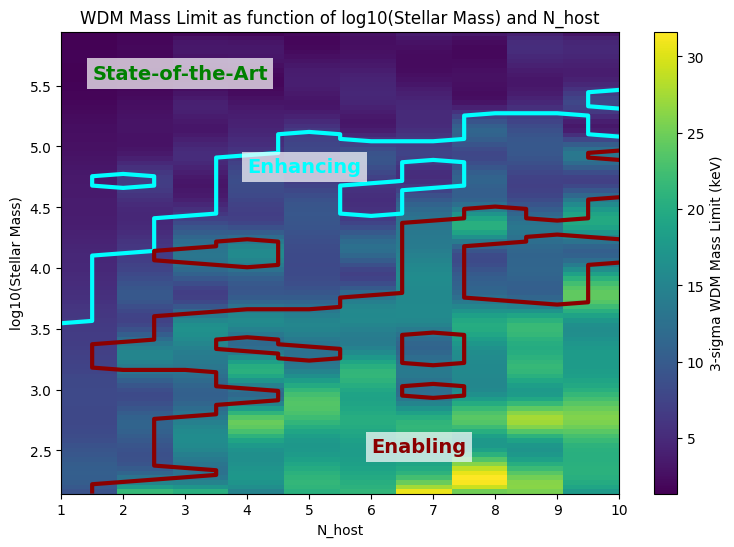

In [7]:
from matplotlib.lines import Line2D

region_state_of_the_art = (wdm_mass_grid < 6.5)
region_enhancing = (wdm_mass_grid >= 6.5) & (wdm_mass_grid < 13)
region_enabling = (wdm_mass_grid >= 13)

# Plot the WDM mass limit grid with region boundaries indicated by contour lines (no color fill)

plt.figure(figsize=(9, 6))
im = plt.imshow(wdm_mass_grid.T, aspect='auto', origin='lower',
                extent=[N_host_range[0], N_host_range[-1], log_Mstar_range[0], log_Mstar_range[-1]],
                cmap='viridis')
plt.colorbar(im, label='3-sigma WDM Mass Limit (keV)')
plt.ylabel('log10(Stellar Mass)')
plt.xlabel('N_host')
plt.title('WDM Mass Limit as function of log10(Stellar Mass) and N_host')

# Draw contour lines for each region boundary
plt.contour(N_host_range, log_Mstar_range, region_state_of_the_art.T, levels=[0.5], colors='cyan', linewidths=3, linestyles='solid', label='State-of-the-Art')
#plt.contour(N_host_range, log_Mstar_range, region_enabling.T, levels=[0.5], colors='orange', linewidths=3, linestyles='solid', label='Enhancing')
plt.contour(N_host_range, log_Mstar_range, region_enabling.T, levels=[0.5], colors='darkred', linewidths=3, linestyles='solid', label='Enabling')

# Add legend for the contour lines
plt.text(1.5, log_Mstar_range[-10], "State-of-the-Art", color='green', fontsize=14, weight='bold', va='center', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.text(4, log_Mstar_range[-30], "Enhancing", color='cyan', fontsize=14, weight='bold', va='center', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.text(6, log_Mstar_range[10], "Enabling", color='darkred', fontsize=14, weight='bold', va='center', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.show()

# Observation Quality vs. Observatory Capability (Panel 2)

In [8]:
# Calculate exposure time for a given RGB star
#
# Authors state that "In order to reach the thresholds proposed for incremental, substantial, or breakthrough progress,
# we must reach g-band magnitudes of 30 mag, 32.5 mag, and 35 mag respectively."
#
# The exposure time is calculated using the formula:

def camera_exptime3(telescope, template, mag, snr_goal, diameter=6.0, silent=False):

    ''' Run a basic SNR calculation that takes in a telescope,
      spectral template, normalization magnitude, and SNR goal
      to compute exptime. For converting magnitude, template,
      and exptime to SNR, use camera_snr.py

        usage:
          exptime, hri = camera_exptime3(telescope, template, mag, snr_goal, diameter=diameter, silent=False)

          positional arguments:

           1-telescope = 'EAC1', 'EAC2', or 'EAC3'. This argument is a string.
             EAC1 = 6 m inner diameter, 7.2 outer diameter hex pattern, off-axis
             EAC2 = 6 m diameter off-axis
             EAC3 = 8 m diameter on-axis

           2-template = your choice of spectral template:
               'Classical T-Tauri Star', 'M1 Dwarf', 'M Dwarf', 'G Dwarf', 'G2V Star',
               'O5V Star', 'B5V Star', 'M2V Star', '10 Myr Starburst', 'QSO',
               'Seyfert 1', 'Seyfert 2', 'Liner', 'Orion Nebula',
               'G191B2B (WD)', 'GD71 (WD)', 'GD153 (WD)', 'Starburst, No Dust',
               'Starburst, E(B-V) = 0.6', 'Elliptical Galaxy', 'Sbc Galaxy', 'NGC 1068',
               'Galaxy with f_esc, HI=1, HeI=1', 'Galaxy with f_esc, HI=0.001, HeI=1',
               'Flat (AB)', 'Flat in F_lambda', 'Blackbody (5000K)', 'Blackbody (100,000K)'

           3-mag = V magnitude to normalize the template spectrum, a float.

           4-snr_goal = desired SNR, per pixel, for each band

           outputs are arrays with the exposure time in each band for FUV, NUV, U, B, V, R, I, J, H, K
       '''

    import astropy.units as u
    from syotools.models import Telescope, Camera, Source, SourcePhotometricExposure

    # Create the basic objects and load SEI-backed telescope/camera throughput data.
    # The post-Nov-2024 syotools refactor pulls telescope_efficiency and
    # instrument_efficiency_{uvis,nir} from the SEI YAML files, so set_from_sei is
    # required (set_from_json does not populate those attributes).
    tel, hri = Telescope(), Camera()
    tel.set_from_sei(telescope)
    tel.effective_aperture = diameter * u.m
    hri.set_from_sei('HRI')

    # Build the Source object (replaces the older sed_id / renorm_sed flow).
    source = Source()
    source.set_sed(template, mag, redshift=0., extinction=0., bandpass='johnson,v')

    hri_exp = SourcePhotometricExposure()
    hri_exp.source = source
    hri_exp._snr = [snr_goal] * u.Unit('electron(1/2)')
    hri_exp.unknown = 'exptime'

    tel.add_camera(hri)
    hri.add_exposure(hri_exp)
    hri_exptime = hri_exp.exptime.to(u.s)

    # Print the current template & SNR goal
    if not silent:
        print("Current SED template: {}".format(source.name))
        print("Current SNR goal: {}".format(snr_goal))
        for bb, ee in zip(hri.bandnames, hri_exptime): print("{}, exptime = {}".format(bb, ee))

    return hri_exptime, hri

In [9]:
# Calculate image exposure times as function of magnitude for different aperture sizes

import math

# Set parameters for the exposure time calculation
telescope = 'EAC2'                  # Telescope model
template = 'G2V Star'               # Spectral template (V-band coverage)
SNR = 5.0                           # SNR goal
Vband_index = 4                     # Location of V band exposure time in output of camera ETC
diameters = [2.4, 4, 5, 6, 7, 8]    # Range of telescope diameters in m

# Ranges of depth and sky coverage to test
survey_depth = np.arange(40)*0.20 + 28.0    # G band apparent magnitude

exponent_array = np.zeros(len(survey_depth))
for i in range(len(survey_depth)):
  for j in range(1, len(diameters)):
    exptime, hri = camera_exptime3(telescope, template, survey_depth[i], SNR, diameter=diameters[3], silent=True)
    t_ref = np.array(exptime[Vband_index])
    D_ref = diameters[0]
    exptime, hri = camera_exptime3(telescope, template, survey_depth[i], SNR, diameter=diameters[j], silent=True)
    t_ratio = np.array(exptime[Vband_index])/t_ref
    exponent = math.log(t_ratio, D_ref/diameters[j])
  exponent_array[i] = exponent

In [ ]:
api.timeinator(yieldinator=mass_limit_yield)

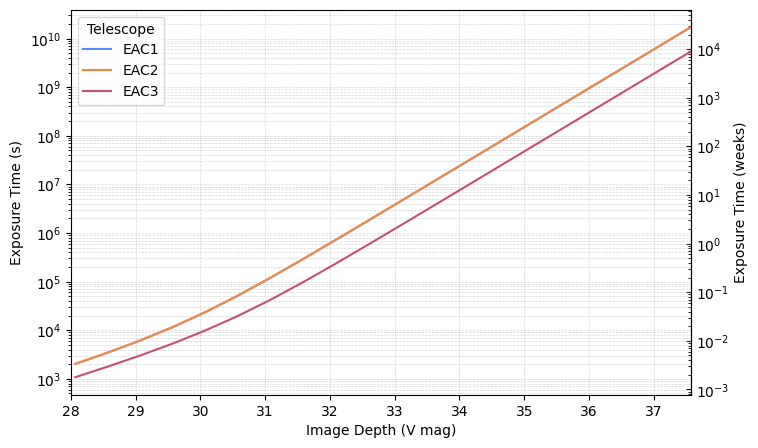

In [10]:
# Calculate image exposure times as function of magnitude for different aperture sizes

import math

# Set parameters for the exposure time calculation
#telescope = 'EAC2'                  # Telescope model
template = 'G2V Star'               # Spectral template (V-band coverage)
#template = 'default_hri_template'  # Use default HRI template
SNR = 5.0                           # SNR goal
Vband_index = 4                     # Location of V band exposure time in output of camera ETC
diameters = [2.4, 4, 5, 6, 7, 8]    # Range of telescope diameters in m

# Ranges of depth and sky coverage to test
survey_depth = np.arange(20)*0.50 + 28.07    # G band apparent magnitude
telescope_type = ['EAC1', 'EAC2', 'EAC3']
diameters = [6, 6, 8]    # Range of telescope diameters in m

# Initialize the exposure time array: shape (num_telescopes, num_depths)
exptime_array = np.zeros((len(telescope_type), len(survey_depth)))

# Loop over telescope types and survey depths
for t_idx, telescope in enumerate(telescope_type):
    for i in range(len(survey_depth)):
        exptime, hri = camera_exptime3(telescope, template, survey_depth[i], SNR, diameter=diameters[t_idx], silent=True)
        exptime_array[t_idx, i] = np.array(exptime[Vband_index])


fig = plt.figure(figsize=(8,5))
ax1 = fig.add_subplot(111)

# Plot exposure time curves for each telescope type
for t_idx, telescope in enumerate(telescope_type):
    ax1.plot(survey_depth, exptime_array[t_idx], label=telescope)

plt.xlim([np.min(survey_depth), np.max(survey_depth)])
ax1.set_xlabel('Image Depth (V mag)')
ax1.set_ylabel('Exposure Time (s)')
ax1.set_yscale('log')
ax1.set_xticks(np.arange(28, 38, 1))
ax1.legend(title='Telescope')
ax1.grid(True, which="both", ls="--")
# Create the secondary x-axis on top
def sec2day(x):
    return x / (3600.0 * 24.0)

def day2sec(x):
    return x * (3600.0 * 24.0)

def sec2week(x):
    return x / (3600.0 * 24.0 * 7.0)

def week2sec(x):
    return x * (3600.0 * 24.0 * 7.0)

secax = ax1.secondary_yaxis('right', functions=(sec2week, week2sec))
secax.set_ylabel(r'Exposure Time (weeks)') #, fontsize=16)
secax.tick_params(axis='both', which='both', direction='in') #, labelsize=14)

plt.savefig("exposure_time_telescopes.pdf", bbox_inches='tight')
plt.show()




Now figure out observations of RGB stars

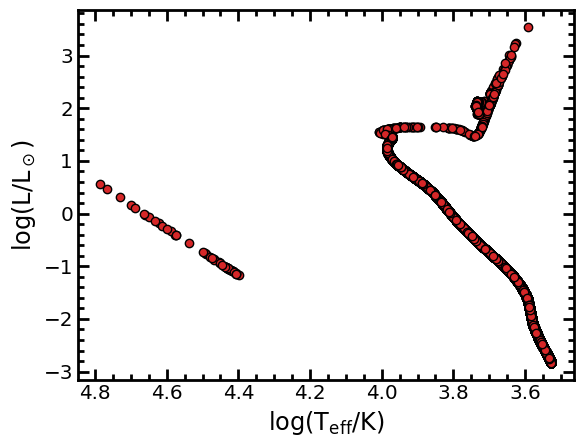

M_i   = -8.23
SBF_i = -1.53
g - i =  0.40

D = 10 Mpc
--------------
m_i   =  21.77
sbf_i =  28.47
g - i =  0.40
D = 10.0 Mpc, m - M = 30.0


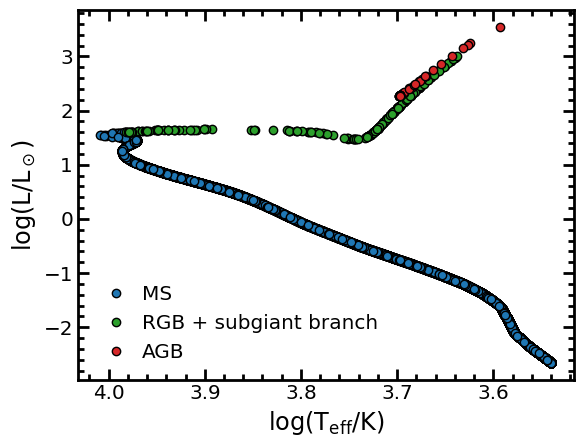

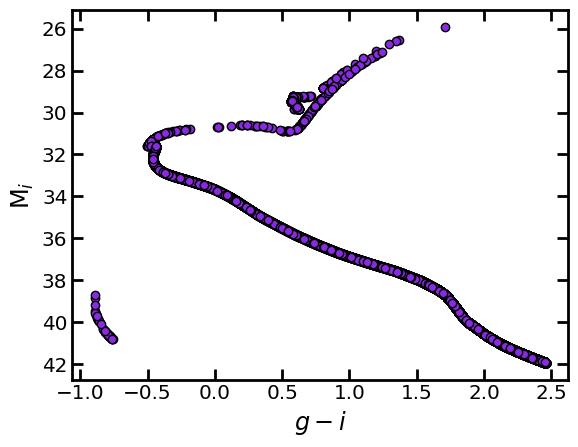

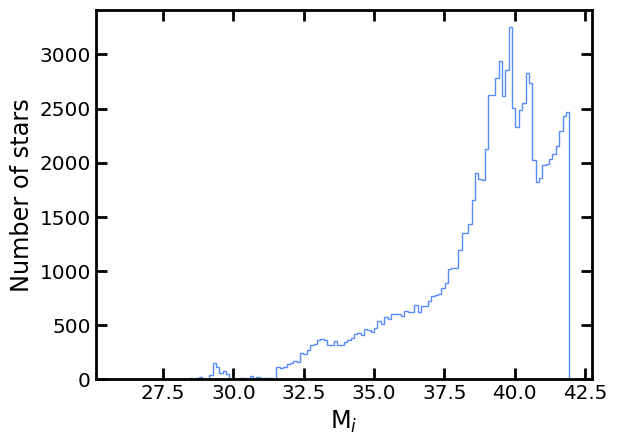

In [11]:
# Run artpop the population synthesis code for dwarf galaxies
# conda activate hwoenv
# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

# Project import
import artpop

# artpop's matplotlib style
plt.style.use(artpop.mpl_style)

# use this random state for reproducibility
rng = np.random.RandomState(112)

ssp = artpop.MISTSSP(
    log_age = 9,          # log of age in years
    feh = -1,             # metallicity [Fe/H]
    phot_system = 'LSST', # photometric system(s)
    num_stars = 1e5,      # number of stars
    imf = 'kroupa',       # default imf
    random_state = rng,   # random state for reproducibility
)

plt.plot(ssp.log_Teff, ssp.log_L, 'o', c='tab:red', mec='k')
plt.gca().invert_xaxis()
plt.minorticks_on()
plt.xlabel(r'$\log(\mathrm{T_{eff}/K})$')
plt.ylabel(r'$\log(\mathrm{L/L_\odot})$')
plt.show()

print(f"M_i   = {ssp.total_mag('LSST_i'): .2f}")
print(f"SBF_i = {ssp.sbf_mag('LSST_i'): .2f}")
print(f"g - i = {ssp.integrated_color('LSST_g', 'LSST_i'): .2f}")

# if a float is given, the unit is assumed to be Mpc
distance = 10
ssp.set_distance(distance)
print(f'\nD = {distance} Mpc\n--------------')
print(f"m_i   = {ssp.total_mag('LSST_i'): .2f}")
print(f"sbf_i = {ssp.sbf_mag('LSST_i'): .2f}")
print(f"g - i = {ssp.integrated_color('LSST_g', 'LSST_i'): .2f}")

# the distance and distance modulus are attributes
print(f'D = {ssp.distance}, m - M = {ssp.dist_mod}')

ssp.phases

# generate boolean phase masks
MS = ssp.select_phase('MS')
RGB = ssp.select_phase('RGB')
AGB = ssp.select_phase('AGB')

plt.plot(ssp.log_Teff[MS], ssp.log_L[MS], 'o',
         label='MS', c='tab:blue', mec='k')
plt.plot(ssp.log_Teff[RGB], ssp.log_L[RGB], 'o',
         label='RGB + subgiant branch',
         c='tab:green', mec='k')
plt.plot(ssp.log_Teff[AGB], ssp.log_L[AGB], 'o',
         label='AGB', c='tab:red', mec='k')

plt.legend(loc='lower left')
plt.gca().invert_xaxis()
plt.minorticks_on()
plt.xlabel(r'$\log(\mathrm{T_{eff}/K})$')
plt.ylabel(r'$\log(\mathrm{L/L_\odot})$');
plt.show()

i=ssp.star_mags('LSST_i')
g=ssp.star_mags('LSST_g')

plt.plot(g-i, i, 'o', c='blueviolet', mec='k')
plt.gca().invert_yaxis()
plt.xlabel(r'$g-i$')
plt.ylabel(r'M$_i$')

plt.show()

# histogram of magnitudes...
counts, bins = np.histogram(i, bins='auto')
plt.stairs(counts, bins)
plt.xlabel(r'M$_i$')
plt.ylabel('Number of stars')
plt.show()

ssp = artpop.MISTSSP(
    log_age = 9,          # log of age in years
    feh = -1,             # metallicity [Fe/H]
    phot_system = 'LSST', # photometric system(s)
    total_mass=1E5, # total mass
    add_remnants=False,
    imf = 'kroupa',       # default imf
    random_state = rng,   # random state for reproducibility
)






In [12]:
def calculate_RGB_int_time(distance_mpc, absolute_magnitude=0, SNR=SNR, telescope='EAC2', template='G2V Star', band_index=Vband_index):

    """
    Calculate the integration time required to detect an RGB star of given absolute magnitude at a given distance.
    Parameters:
        distance_mpc (float): Distance to the star in Mpc.
        absolute_magnitude (float): Absolute magnitude of the RGB star.
        SNR (float): Desired signal-to-noise ratio.
        telescope (str): Telescope model.
        template (str): Spectral template.
        diameter (float): Telescope diameter in meters.
        band_index (int): Index of the band to use for exposure time.

    Returns:
        float: Required integration time in seconds.
    """
    # Convert distance to apparent magnitude
    distance_pc = distance_mpc * 1e6
    apparent_mag = absolute_magnitude + 5 * np.log10(distance_pc) - 5

    # Use camera_exptime3 to get exposure time
    exptime, hri = camera_exptime3(telescope, template, apparent_mag, SNR, silent=True)

    return np.array(exptime[band_index])

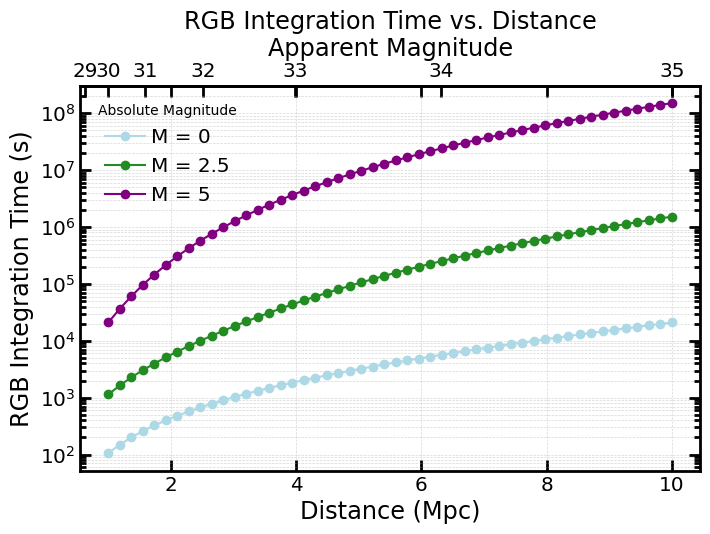

In [13]:

# Plot RGB integration time as a function of distance up to 10 Mpc for different absolute magnitudes,


distances = np.linspace(1, 10, 50)  # Avoid zero, start from 1 Mpc to 10 Mpc
abs_mags = [0, 2.5, 5]
labels = [f"M = {m}" for m in abs_mags]
colors = ['lightblue', 'forestgreen', 'purple']  # Avoid orange, red, brown

fig, ax1 = plt.subplots(figsize=(8,5))

for m, label, color in zip(abs_mags, labels, colors):
    integration_times = [calculate_RGB_int_time(d, absolute_magnitude=m) for d in distances]
    ax1.plot(distances, integration_times, marker='o', label=label, color=color)

ax1.set_xlabel('Distance (Mpc)')
ax1.set_ylabel('RGB Integration Time (s)')
ax1.set_title('RGB Integration Time vs. Distance')
ax1.set_yscale('log')
ax1.grid(True, which='both', ls='--')
ax1.legend(title='Absolute Magnitude')

# Add a secondary x-axis for apparent magnitude
def dist_to_appmag(distance, abs_mag):
    distance_pc = distance * 1e6
    return abs_mag + 5 * np.log10(distance_pc) - 5.

# Use the faintest absolute magnitude for the secondary axis
abs_mag_for_top = abs_mags[-1]
app_mag_ticks = dist_to_appmag(distances, abs_mag_for_top)

def forward(x):
    return dist_to_appmag(x, abs_mag_for_top)
def inverse(x):
    return 10**((x - abs_mag_for_top)/5 + 1) / 1e6

secax = ax1.secondary_xaxis('top', functions=(forward, inverse))
secax.set_xlabel(f'Apparent Magnitude') #(M = {abs_mag_for_top})')

plt.show()

In [14]:
# Now calculate the integration time per galaxy as a function of distance out to 20 Mpc
# survey area per galaxy is originally set to an imager area of 43200 arcsec2 (based on LUVOIR),
# a test survey area of 4712 kpc2 (an arbitrary choice of an annulus between 20-40 kpc from a target galaxy
# assume a 2' x 2' imager field of view, which is 14400 arcsec2, so 3 pointings are needed to cover the 43200 arcsec2 area
# this is equivalent to a circular area with a radius of 117 kpc at 20 Mpc


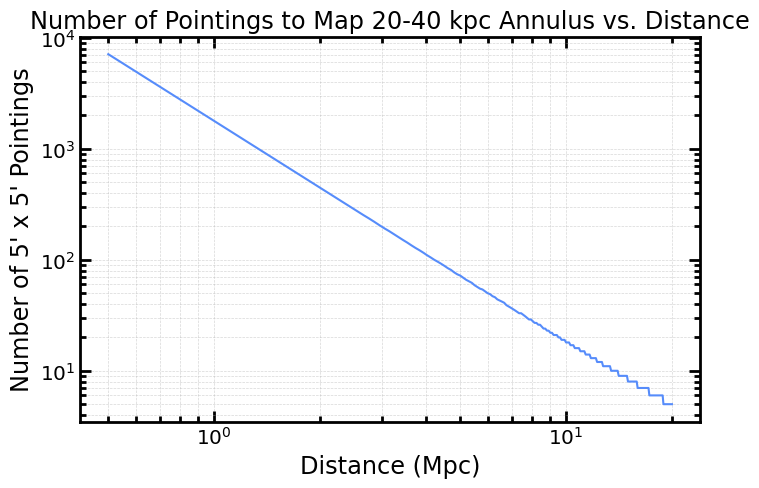

In [15]:

# Calculate the number of pointings needed for a 2' x 2' FoV imager to map an annulus from 20-40 kpc
# around a galaxy, as a function of distance from 0 to 20 Mpc.

import numpy as np
import matplotlib.pyplot as plt

# Imager field of view in arcmin and arcsec
fov_arcmin = 5  # 2 arcmin
fov_arcsec = fov_arcmin * 60  # 120 arcsec
fov_area_arcsec2 = fov_arcsec ** 2  # area in arcsec^2
#print(fov_area_arcsec2)

# Annulus parameters
r_in_kpc = 20
r_out_kpc = 40

# Distance grid in Mpc
distances_mpc = np.linspace(0.5, 20, 200)  # avoid zero to prevent division by zero

# Calculate projected angular radii in arcsec for each distance
def kpc_to_arcsec(r_kpc, d_mpc):
    # 1 radian = 206265 arcsec
    # r_kpc at d_mpc subtends theta = r_kpc / (d_mpc * 1e3) radians
    # arcsec = theta * 206265
    return (r_kpc / (d_mpc * 1e3)) * 206265

r_in_arcsec = kpc_to_arcsec(r_in_kpc, distances_mpc)
r_out_arcsec = kpc_to_arcsec(r_out_kpc, distances_mpc)
#print(r_in_arcsec)
#print(r_out_arcsec)

# Area of annulus in arcsec^2
annulus_area_arcsec2 = np.pi * (r_out_arcsec**2 - r_in_arcsec**2)
#print(annulus_area_arcsec2)

# Number of pointings needed (round up to cover the area)
num_pointings = np.ceil(annulus_area_arcsec2 / fov_area_arcsec2)

plt.figure(figsize=(8,5))
#plt.plot(distances_mpc, annulus_area_arcsec2, label='Annulus Area (arcsec^2)')
plt.plot(distances_mpc, num_pointings)
plt.xlabel('Distance (Mpc)')
plt.ylabel('Number of 5\' x 5\' Pointings')
plt.title('Number of Pointings to Map 20-40 kpc Annulus vs. Distance')
plt.yscale('log')
plt.xscale('log')
plt.grid(True, which='both', ls='--')
plt.show()

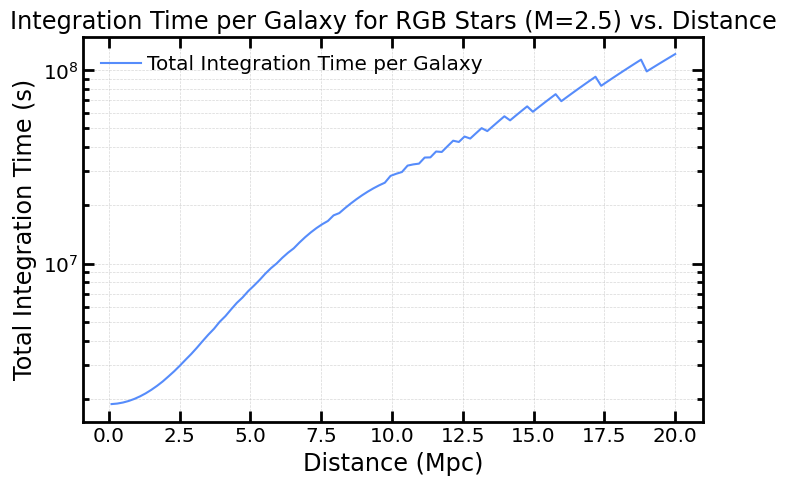

In [16]:
# Calculate integration time per galaxy for RGB stars (M=2.5) as a function of distance (0.1 to 20 Mpc)
# Includes number of pointings needed for each distance

distances = np.linspace(0.1, 20, 100)
abs_mag = 2.5

# Calculate integration time for each distance
integration_times = np.array([calculate_RGB_int_time(d, absolute_magnitude=abs_mag) for d in distances])

# Imager field of view in arcmin and arcsec (matching previous cells)
fov_arcmin = 5  # arcmin
fov_arcsec = fov_arcmin * 60
fov_area_arcsec2 = fov_arcsec ** 2

# Annulus parameters
r_in_kpc = 20
r_out_kpc = 40

def kpc_to_arcsec(r_kpc, d_mpc):
    return (r_kpc / (d_mpc * 1e3)) * (180. / np.pi  * 3600.)  # convert radians to arcsec

r_in_arcsec = kpc_to_arcsec(r_in_kpc, distances)
r_out_arcsec = kpc_to_arcsec(r_out_kpc, distances)
annulus_area_arcsec2 = np.pi * (r_out_arcsec**2 - r_in_arcsec**2)
num_pointings = np.ceil(annulus_area_arcsec2 / fov_area_arcsec2)

# Total integration time per galaxy (integration time per pointing * number of pointings)
total_integration_time = integration_times * num_pointings

plt.figure(figsize=(8,5))
plt.plot(distances, total_integration_time, label='Total Integration Time per Galaxy')
plt.xlabel('Distance (Mpc)')
plt.ylabel('Total Integration Time (s)')
plt.title('Integration Time per Galaxy for RGB Stars (M=2.5) vs. Distance')
plt.yscale('log')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()

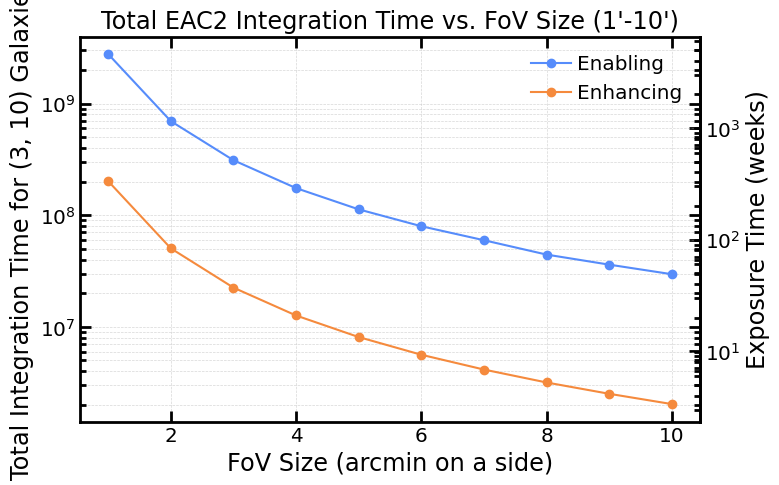

In [17]:
# Calculate total integration time for 10 galaxies at fixed distances (1-10 Mpc)
# as a function of square FoV size (from 1' to 10' on a side, 10 values)

galaxy_enabling = np.arange(1, 11)  # 1 to 10 Mpc
galaxy_enhancing = np.arange(1, 4)  # 1 to 3 Mpc, 3 galaxies
abs_mag = 2.5  # Use same RGB absolute magnitude as before

# FoV sizes in arcmin (1' to 10', 10 values)
fov_sizes_arcmin = np.linspace(1, 10, 10)
total_times_enabling = []
total_times_enhancing = []

for fov_arcmin in fov_sizes_arcmin:
    fov_arcsec = fov_arcmin * 60
    fov_area_arcsec2 = fov_arcsec ** 2

    # For each galaxy, calculate number of pointings and integration time for Enabling case
    total_time_enabling = 0
    for d in galaxy_enabling:
        # Annulus parameters
        r_in_kpc = 20   # 20 kpc is the inner radius of the annulus
        r_out_kpc = 40  # 40 kpc is the outer radius of the annulus

        # Convert annulus to arcsec at this distance
        def kpc_to_arcsec(r_kpc, d_mpc):
            return (r_kpc / (d_mpc * 1e3)) * (180. / np.pi  * 3600.)  # convert radians to arcsec

        r_in_arcsec = kpc_to_arcsec(r_in_kpc, d)
        r_out_arcsec = kpc_to_arcsec(r_out_kpc, d)
        annulus_area_arcsec2 = np.pi * (r_out_arcsec**2 - r_in_arcsec**2)
        num_pointings = np.ceil(annulus_area_arcsec2 / fov_area_arcsec2) # simplied calculation of number of pointings needed to cover the annulus area with the given FoV size

        # Integration time for this galaxy
        int_time = calculate_RGB_int_time(d, telescope='EAC2', absolute_magnitude=abs_mag)
        total_time_enabling += int_time * num_pointings

    total_times_enabling.append(total_time_enabling)

    # For each galaxy, calculate number of pointings and integration time for Enabling case
    total_time_enhancing = 0
    for d in galaxy_enhancing:
        # Annulus parameters (fixed)
        r_in_kpc = 20
        r_out_kpc = 40  # already defined

        # Convert annulus to arcsec at this distance
        def kpc_to_arcsec(r_kpc, d_mpc):
            return (r_kpc / (d_mpc * 1e3)) * (180. / np.pi  * 3600.)  # convert radians to arcsec

        r_in_arcsec = kpc_to_arcsec(r_in_kpc, d)
        r_out_arcsec = kpc_to_arcsec(r_out_kpc, d)
        annulus_area_arcsec2 = np.pi * (r_out_arcsec**2 - r_in_arcsec**2)
        num_pointings = np.ceil(annulus_area_arcsec2 / fov_area_arcsec2)

        # Integration time for this galaxy
        int_time = calculate_RGB_int_time(d, telescope='EAC2',absolute_magnitude=abs_mag)
        total_time_enhancing += int_time * num_pointings

    total_times_enhancing.append(total_time_enhancing)

# Plot total integration time vs. FoV size
fig = plt.figure(figsize=(8,5))
ax1 = fig.add_subplot(111)

#plt.figure(figsize=(8,5))
ax1.plot(fov_sizes_arcmin, total_times_enabling, marker='o', label='Enabling')
ax1.plot(fov_sizes_arcmin, total_times_enhancing, marker='o', label='Enhancing')
ax1.set_xlabel("FoV Size (arcmin on a side)")
ax1.set_ylabel("Total Integration Time for (3, 10) Galaxies")
ax1.set_title("Total EAC2 Integration Time vs. FoV Size (1'-10')")
ax1.set_yscale('log')
ax1.grid(True, which='both', ls='--')
ax1.legend()

# Create the secondary x-axis on top
def sec2day(x):
    return x / (3600.0 * 24.0)

def day2sec(x):
    return x * (3600.0 * 24.0)

def sec2week(x):
    return x / (3600.0 * 24.0 * 7.0)

def week2sec(x):
    return x * (3600.0 * 24.0 * 7.0)


secax = ax1.secondary_yaxis('right', functions=(sec2week, week2sec))
secax.set_ylabel(r'Exposure Time (weeks)') #, fontsize=16)
secax.tick_params(axis='both', which='both', direction='in') #, labelsize=14)

plt.savefig("Panel2_FoV.pdf", bbox_inches='tight')
plt.show()

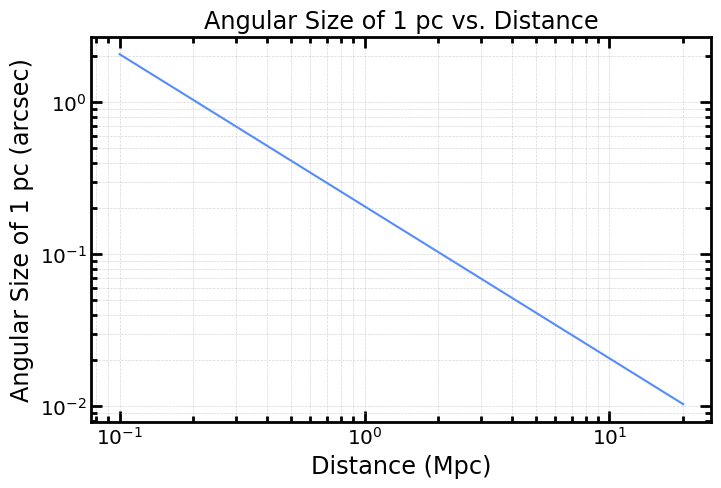

In [18]:

# Calculate the angular size (in arcseconds) subtended by 1 pc as a function of distance (0.1 to 20 Mpc)
import numpy as np
import matplotlib.pyplot as plt

distances_mpc = np.linspace(0.1, 20, 200)  # Distance in Mpc
pc = 1  # Physical size in parsec

angular_resolution_arcsec = (pc / (distances_mpc * 1e6)) * (180. / np.pi * 3600.)

plt.figure(figsize=(8,5))
plt.plot(distances_mpc, angular_resolution_arcsec)
plt.xlabel('Distance (Mpc)')
plt.ylabel('Angular Size of 1 pc (arcsec)')
plt.title('Angular Size of 1 pc vs. Distance')
plt.yscale('log')
plt.xscale('log')
plt.grid(True, which='both', ls='--')
plt.show()

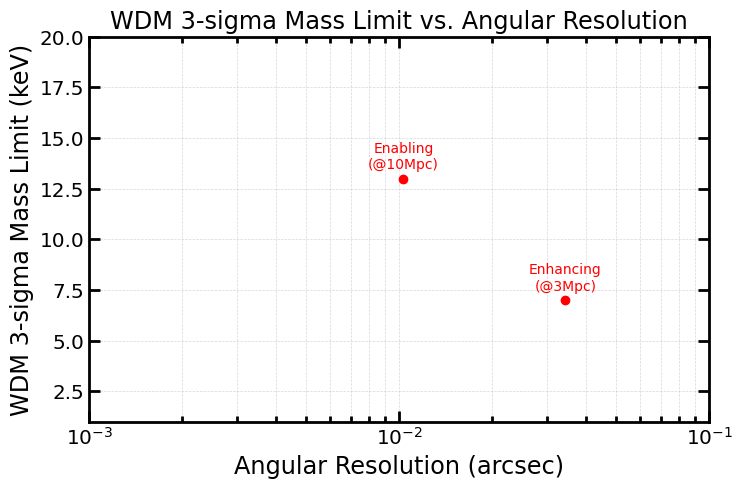

In [19]:

import numpy as np
import matplotlib.pyplot as plt

wdm_mass_limits_vs_distance = [7.0, 13.0]

# Calculate angular resolution (arcsec) for 1 pc at distances from 1 to 10 Mpc
distances_mpc = np.linspace(1, 10, len(wdm_mass_limits_vs_distance))
pc = 1
angular_resolution_arcsec = (pc / (distances_mpc * 1e6)) * 206265

# Plot WDM 3-sigma mass limit vs. angular resolution
fig, ax = plt.subplots(figsize=(8,5))
ax.set_xlabel('Angular Resolution (arcsec)')
ax.set_xlim(0.001, 0.1)
ax.set_xscale('log')
ax.set_ylim(1, 20)
ax.set_ylabel('WDM 3-sigma Mass Limit (keV)')
ax.set_title('WDM 3-sigma Mass Limit vs. Angular Resolution')

# Calculate 0.5 * angular resolution at 3 Mpc and 10 Mpc
def ang_res(pc, d_mpc):
    return (pc / (d_mpc * 1e6)) * 206265

ang_3mpc = ang_res(1, 3)
ang_10mpc = ang_res(1, 10)

# Plot and label the points
ax.plot(0.5 * ang_3mpc, 7, 'ro')
ax.text(0.5 * ang_3mpc, 7 + 0.5, 'Enhancing\n(@3Mpc)', color='red', ha='center')

ax.plot(0.5 * ang_10mpc, 13, 'ro')
ax.text(0.5 * ang_10mpc, 13 + 0.5, 'Enabling\n(@10Mpc)', color='red', ha='center')

ax.grid(True, which='both', ls='--')
plt.savefig("Panel2_resolution.pdf", bbox_inches='tight')
plt.show()